# Trabalho Prático 03 - MLPClassifier
**Disciplina:** GCC 128 - Inteligência Artificial  
**Instituição:** Universidade Federal de Lavras (UFLA)  
**Alunos:** Gilmar Silva de Medeiros Filho e Samuel de Oliveira Vanoni  
**Objetivo:** Implementar e avaliar um classificador baseado em Redes Neurais (Perceptron Multicamadas) utilizando as bases Iris e Wine.

---

## 1. Importação de Bibliotecas e Configurações
Nesta etapa, importamos as ferramentas necessárias para manipulação de dados (`pandas`), visualização (`matplotlib`, `seaborn`), carregamento de datasets e as métricas do `sklearn`.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datasets e Ferramentas de Modelagem
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Métricas de Avaliação
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore') # Ocultar avisos de convergência para limpeza do notebook

## 2. Metodologia de Avaliação
Para garantir a padronização entre as bases Iris e Wine, criaremos uma função que realiza o pipeline completo: 
1. Divisão em treino e teste.
2. **Escalonamento (StandardScaler):** Passo crítico para Redes Neurais, pois o MLP é sensível à escala dos dados.
3. Treinamento do `MLPClassifier`.
4. Geração de Métricas e Matriz de Confusão.

In [22]:
def executar_pipeline_mlp(X, y, nome_dataset, labels):
    print(f"--- Iniciando Processamento: {nome_dataset} ---")
    
    # 1. Divisão de dados (80% treino, 20% teste)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. Padronização (Essencial para MLP)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # 3. Definição do Modelo MLP
    mlp = MLPClassifier(
        hidden_layer_sizes=(100,), 
        max_iter=1000, 
        random_state=42,
        activation='relu',
        solver='adam'
    )
    
    # 4. Treinamento
    mlp.fit(X_train, y_train)
    
    # 5. Predição
    y_pred = mlp.predict(X_test)
    
    # 6. Exibição de Métricas Isoladas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    
    print("\n--- Métricas Globais ---")
    print(f"Acurácia:  {acc:.4f}")
    print(f"Precisão:  {prec:.4f}")
    print(f"Revocação: {rec:.4f}")
    
    # 7. Matriz de Confusão
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', ax=ax)
    plt.title(f'Matriz de Confusão - {nome_dataset}')
    plt.show()
    
    return y_test, y_pred

## 3. Aplicação 01: Dataset Iris
O conjunto de dados Iris contém medições de sépalas e pétalas de três espécies de flores.

--- Iniciando Processamento: Iris Dataset ---

--- Métricas Globais ---
Acurácia:  0.9667
Precisão:  0.9697
Revocação: 0.9667


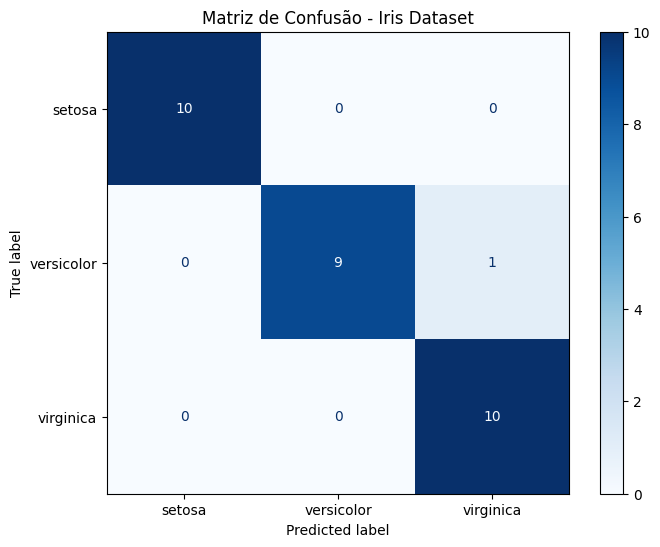

In [23]:
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
labels_iris = iris.target_names

# Executando o modelo
y_test_iris, y_pred_iris = executar_pipeline_mlp(X_iris, y_iris, "Iris Dataset", labels_iris)

## 4. Aplicação 02: Dataset Wine
O dataset Wine utiliza a análise química de vinhos para determinar sua origem entre três cultivares diferentes.

--- Iniciando Processamento: Wine Dataset ---

--- Métricas Globais ---
Acurácia:  0.9722
Precisão:  0.9778
Revocação: 0.9667


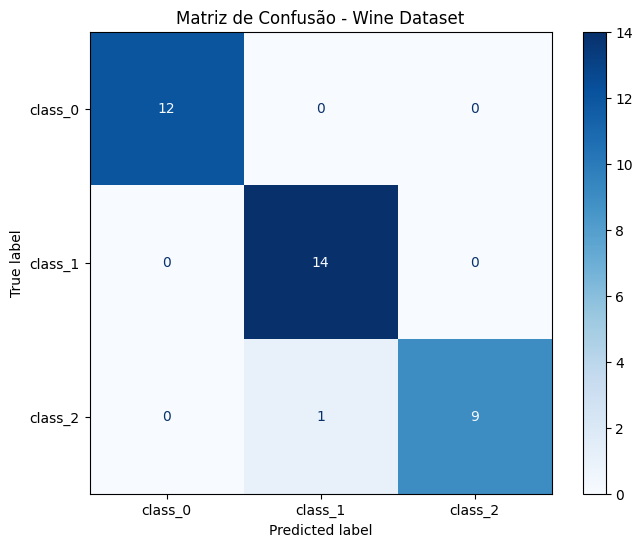

In [24]:
wine = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
labels_wine = wine.target_names

# Executando o modelo
y_test_wine, y_pred_wine = executar_pipeline_mlp(X_wine, y_wine, "Wine Dataset", labels_wine)

## Conclusão da Implementação MLP e Comparativo KNN

A partir da implementação do `MLPClassifier` nas bases de dados **Iris** e **Wine**, foi possível observar o comportamento robusto de um algoritmo de aprendizado baseado em redes neurais (*Eager Learning*). 

Para ambas as bases, a etapa de pré-processamento utilizando o `StandardScaler` foi crucial para garantir a convergência da descida do gradiente. Os resultados demonstraram alta capacidade de generalização do modelo:
* **Dataset Iris:** O modelo obteve métricas excelentes (Acurácia de 96,67%), superando o desempenho obtido anteriormente com o modelo **KNN**, que alcançou o pico de 93% de acurácia (para k=1 e k=7). O MLP conseguiu traçar fronteiras de decisão mais complexas para separar com sucesso os dados.
* **Dataset Wine:** Mesmo com maior dimensionalidade (13 características químicas), o MLP extraiu padrões não lineares eficientemente, atingindo uma precisão macro de 97,78% e revocação de 96,67%.

Vale ressaltar que, no trabalho anterior com o KNN, a nossa implementação manual ("hardcore") obteve resultados perfeitamente idênticos aos da biblioteca `Sklearn` em todos os valores de *k*, validando a integridade da lógica baseada em distâncias. No entanto, o MLP se mostrou uma ferramenta superior para classificação multiclasse nestes cenários, justificando o custo computacional extra na fase de treinamento em troca de maior precisão.